In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.kinematic_vocabulary import KinematicVocabulary
from src_final.models.analysis import leakage_free_residual_analysis
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_model
from src_final.models.analysis import NestedFeatureSelector

Load data and extract window features

In [2]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Loading processed data:   0%|          | 0/86 [00:00<?, ?it/s]

Extracting Right Features: 100%|██████████| 83/83 [01:14<00:00,  1.11it/s]


In [3]:
df_pc1_features = pd.read_csv("data/metrics/global_pc1_features.csv")
df_pc1_features['video_id'] = df_window_features['video_id'].unique()

### **Start With Leaky Version Where the Clustering is Fitted on the Entire Data**

In [4]:
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_window_features[df_window_features['total_path'] >= 45].copy()
else:
    df_window = df_window_features.copy()

In [5]:
from sklearn.preprocessing import PowerTransformer
p_tf = PowerTransformer(method='yeo-johnson', standardize=False)

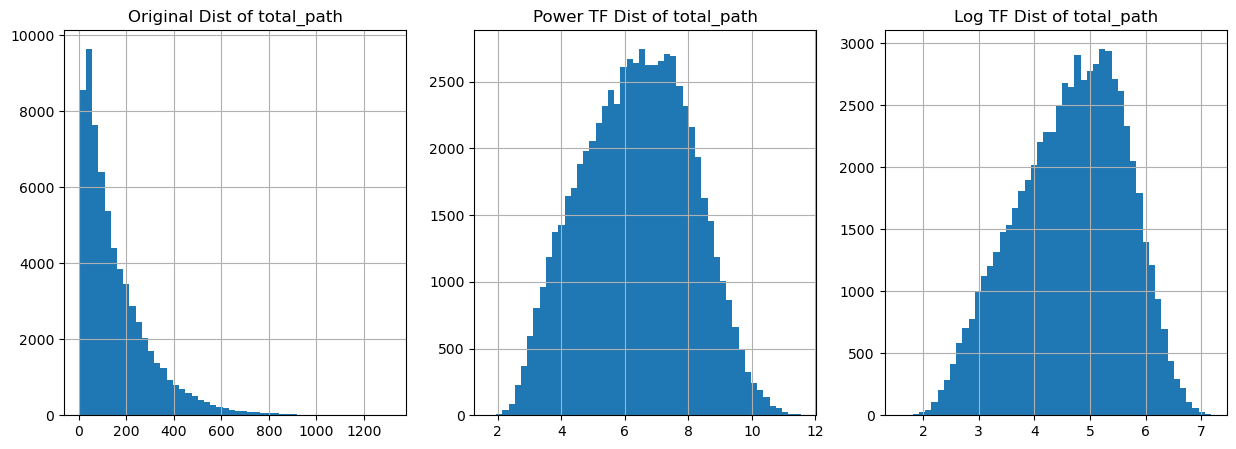

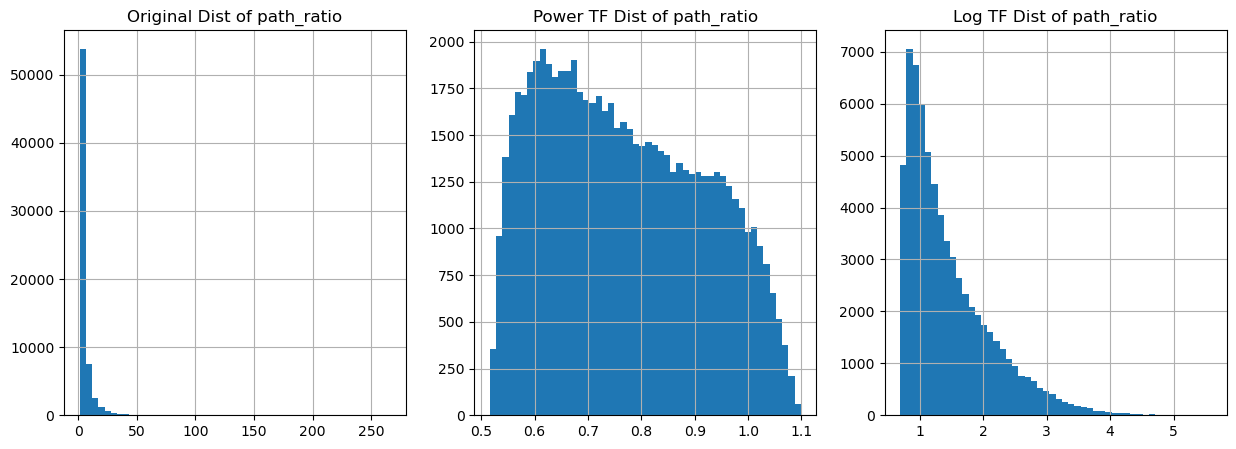

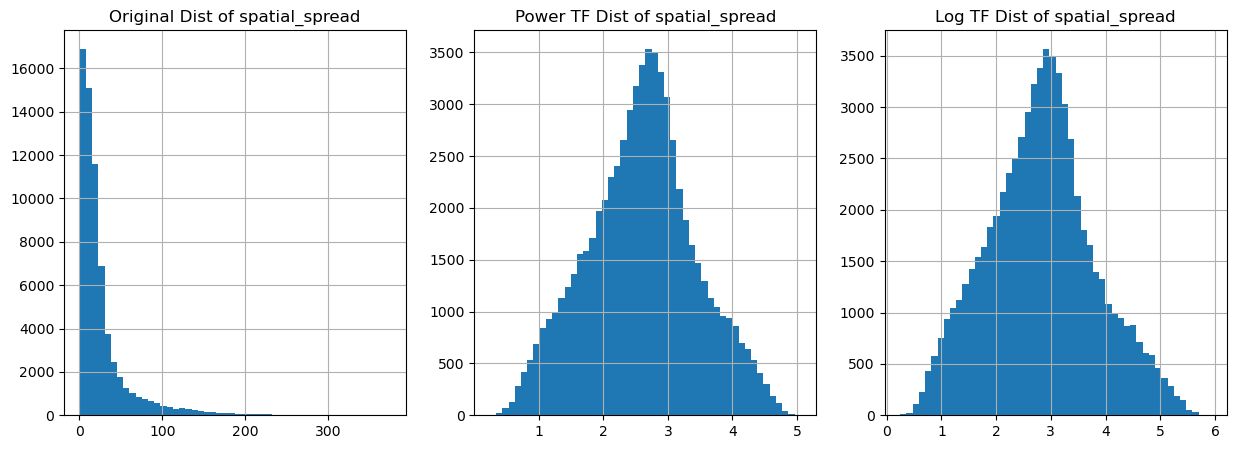

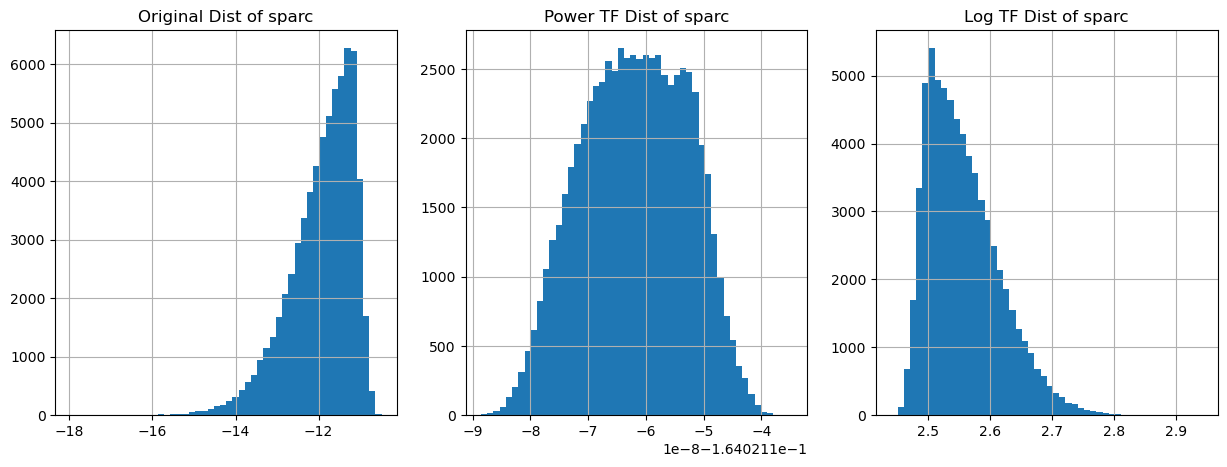

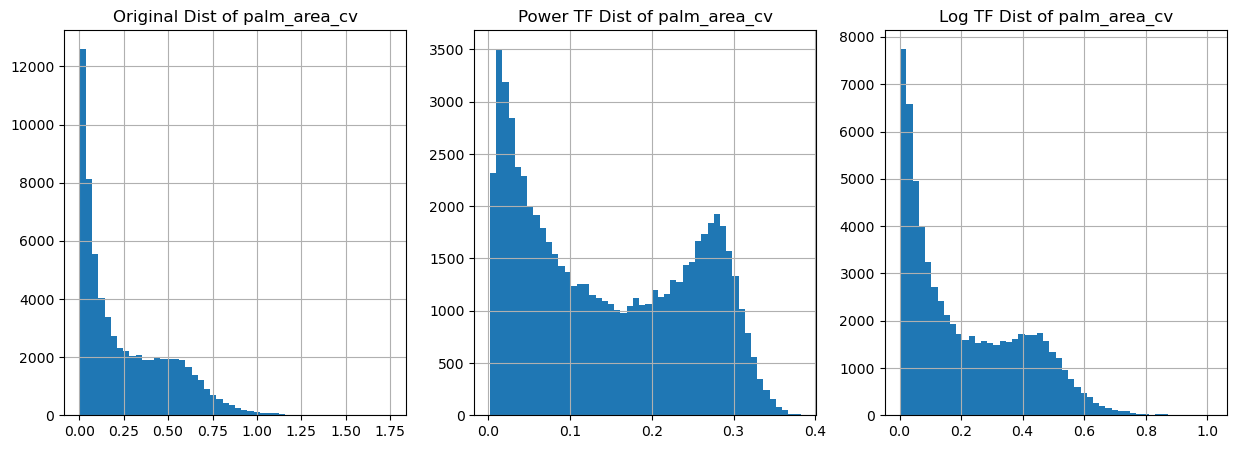

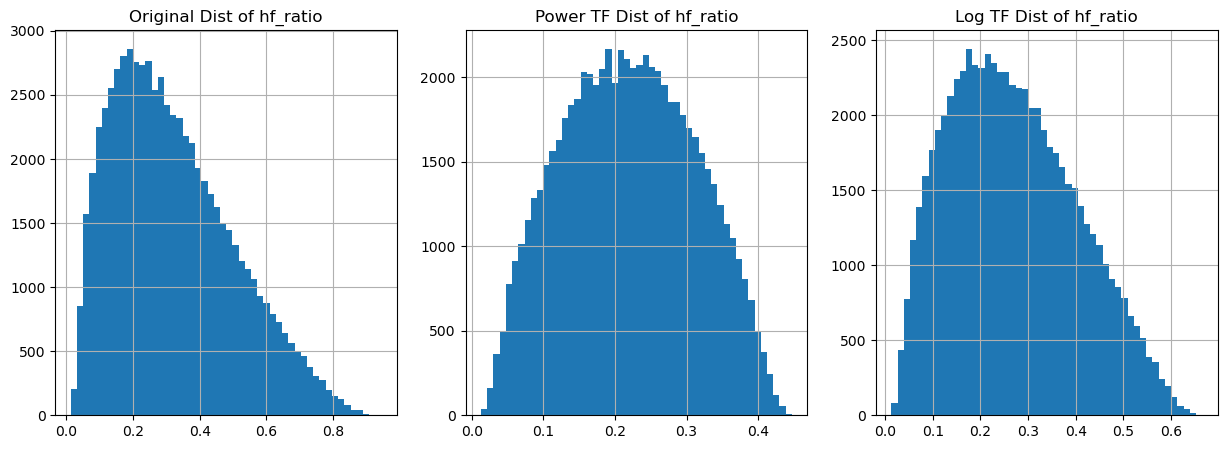

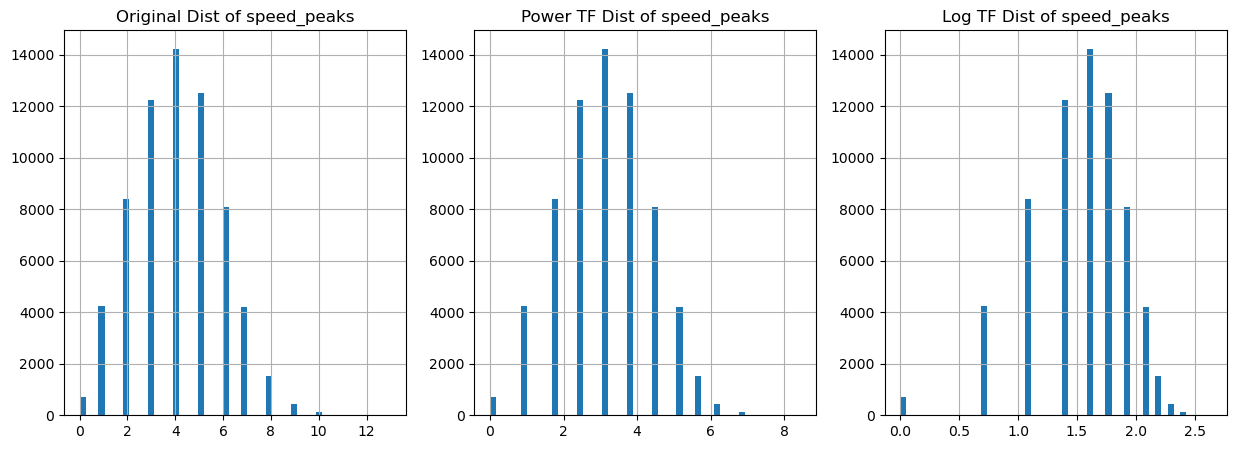

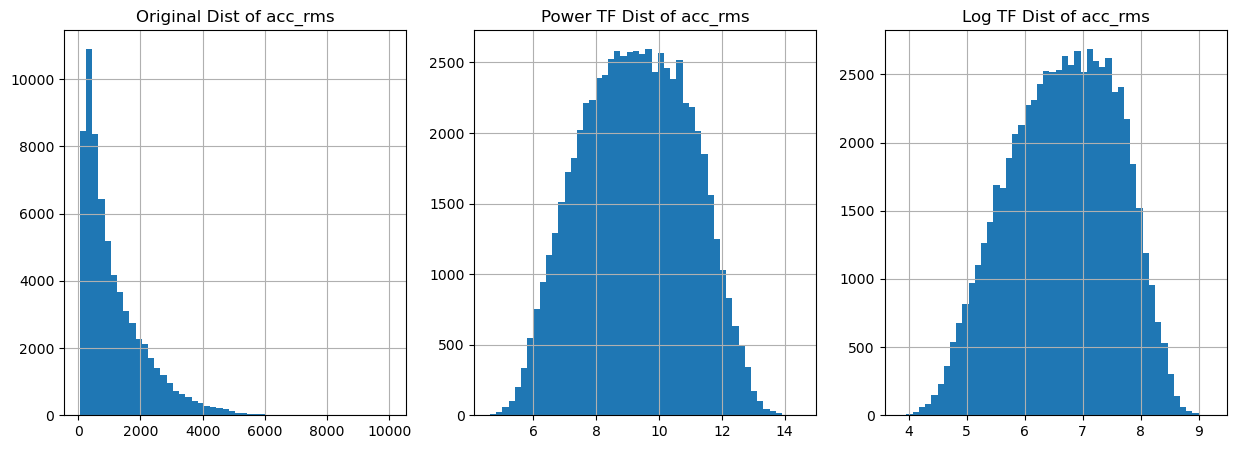

In [6]:
import matplotlib.pyplot as plt

for feat in ['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'hf_ratio', 'speed_peaks', 'acc_rms']:

    X = df_window_features[feat]
    X_transformed = p_tf.fit_transform(X.values.reshape(-1, 1))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Original Dist of {feat}")
    df_window_features[feat].hist(bins=50)

    plt.subplot(1, 3, 2)
    plt.title(f"Power TF Dist of {feat}")  
    pd.Series(X_transformed.flatten()).hist(bins=50)

    plt.subplot(1, 3, 3)
    plt.title(f"Log TF Dist of {feat}")
    df_window_features[feat].apply(lambda x: np.log1p(np.abs(x))).hist(bins=50)

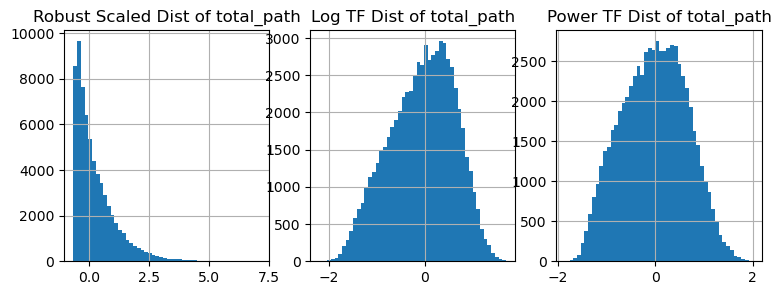

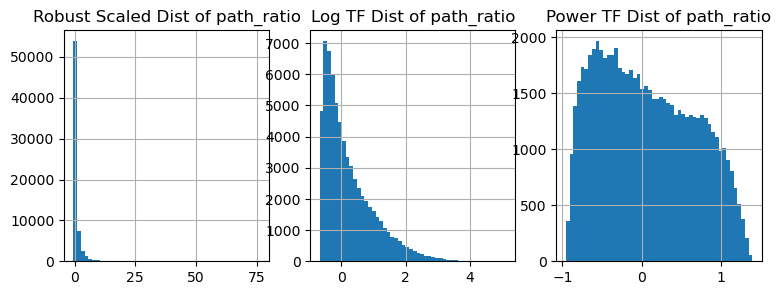

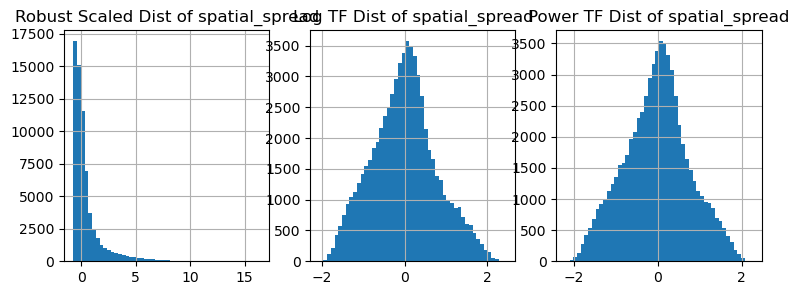

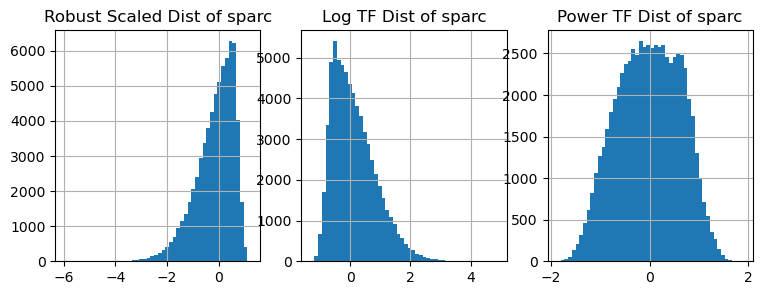

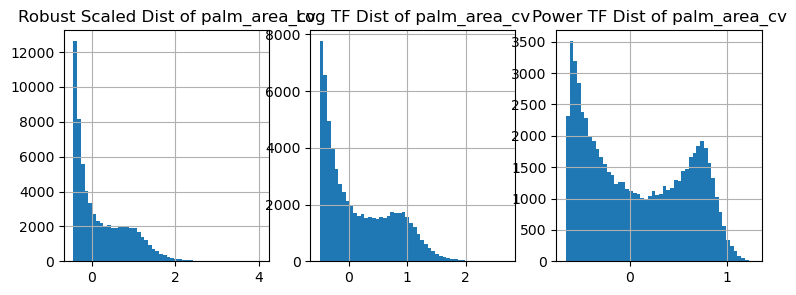

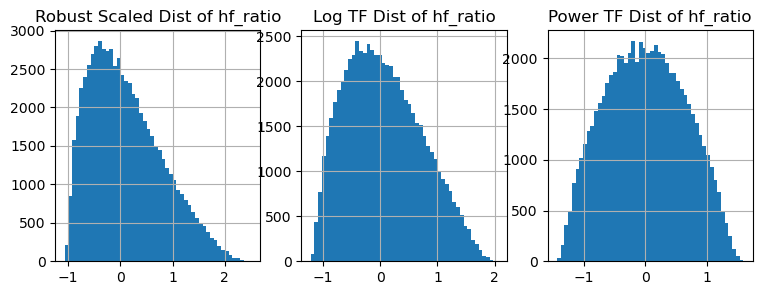

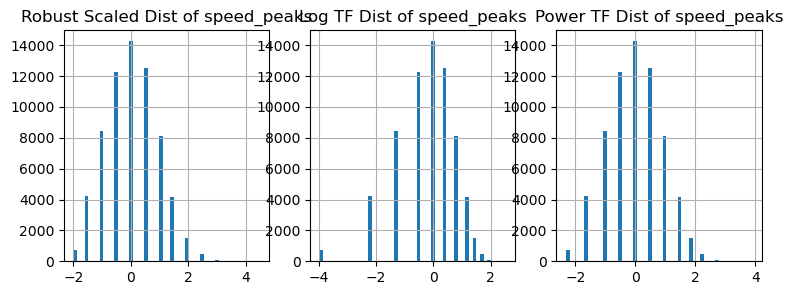

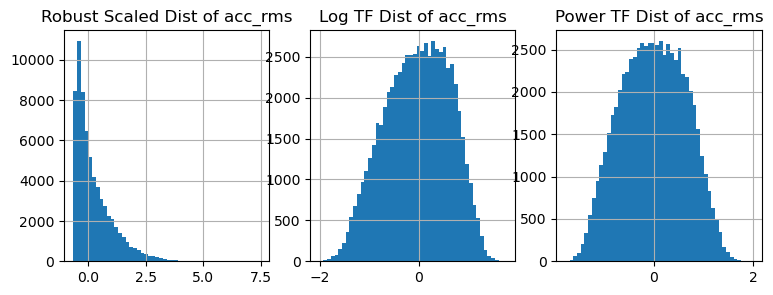

In [7]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

for feat in ['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'hf_ratio', 'speed_peaks', 'acc_rms']:

    X = df_window_features[feat]
    X_scaled = scaler.fit_transform(X.values.reshape(-1, 1))

    plt.figure(figsize=(9, 3))
    plt.subplot(1, 3, 1)
    plt.title(f"Robust Scaled Dist of {feat}")
    pd.Series(X_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 2)
    plt.title(f"Log TF Dist of {feat}")
    X_tf_scaled = scaler.fit_transform(df_window_features[feat].apply(lambda x: np.log1p(np.abs(x))).values.reshape(-1, 1))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 3)
    plt.title(f"Power TF Dist of {feat}")
    X_tf_scaled = scaler.fit_transform(p_tf.fit_transform(X.values.reshape(-1, 1)))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

In [8]:
# intercorrelation of features
feature_cols = [col for col in df_window.columns if col not in ['video_id', 'participant_id', 'window_start_frame', 'is_idle']]
corr_matrix = df_window[feature_cols].corr()
corr_matrix

# => vel_p90 is redundant with total_path

,total_path,path_ratio,spatial_spread,zvr,sparc,hf_ratio,speed_peaks,acc_rms,palm_area_cv
total_path,1.000000,0.122232,0.825992,-0.577230,0.133147,-0.049964,-0.192246,0.824693,0.367741
path_ratio,0.122232,1.000000,-0.174740,-0.224468,-0.189357,0.390943,0.332000,0.320855,0.214029
spatial_spread,0.825992,-0.174740,1.000000,-0.346220,0.301928,-0.408098,-0.452006,0.455553,0.156819
zvr,-0.577230,-0.224468,-0.346220,1.000000,0.134814,-0.211127,-0.154301,-0.542506,-0.426428
sparc,0.133147,-0.189357,0.301928,0.134814,1.000000,-0.563523,-0.491316,-0.009282,-0.079093
hf_ratio,-0.049964,0.390943,-0.408098,-0.211127,-0.563523,1.000000,0.703210,0.245432,0.193902
speed_peaks,-0.192246,0.332000,-0.452006,-0.154301,-0.491316,0.703210,1.000000,0.108982,0.157596
acc_rms,0.824693,0.320855,0.455553,-0.542506,-0.009282,0.245432,0.108982,1.000000,0.455832
palm_area_cv,0.367741,0.214029,0.156819,-0.426428,-0.079093,0.193902,0.157596,0.455832,1.000000


In [63]:
vocab = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=5,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          power_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )

"""df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
vocab = KinematicVocabulary(n_clusters=20, random_state=42, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'bimanual_dist_mean', 'bimanual_sync'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc'])
df_window = df_bimanual.copy()"""

vocab.fit(df_window)
df_voc = vocab.transform(df_window)
df_voc.head(5)


,SurgeMe_0,SurgeMe_1,SurgeMe_2,SurgeMe_3,SurgeMe_4,SurgeMe_5,SurgeMe_6,SurgeMe_7,SurgeMe_8,SurgeMe_9,SurgeMe_10,SurgeMe_11,SurgeMe_12,SurgeMe_13,SurgeMe_14,SurgeMe_15,SurgeMe_16,SurgeMe_17
"(2024-01-15_13-18-23, 1)",0.056066,0.064408,0.046351,0.061597,0.059523,0.051608,0.057827,0.042986,0.066335,0.061619,0.060311,0.050040,0.037516,0.055290,0.054782,0.054860,0.054809,0.064073
"(2024-01-15_13-37-36, 1)",0.055636,0.061140,0.047358,0.055373,0.060100,0.047778,0.060066,0.046719,0.064878,0.059987,0.063267,0.054547,0.039437,0.055786,0.053875,0.058521,0.053776,0.061757
"(2024-01-15_14-03-23, 1)",0.073610,0.050151,0.043540,0.050002,0.048005,0.044017,0.050062,0.058892,0.056443,0.056499,0.067260,0.072020,0.037072,0.052698,0.060894,0.058908,0.060338,0.059589
"(2024-01-15_14-32-45, 2)",0.050044,0.066360,0.054205,0.056661,0.065503,0.044042,0.063802,0.042443,0.069565,0.059694,0.056513,0.042641,0.044166,0.050700,0.055561,0.057766,0.051759,0.068573
"(2024-01-15_15-05-31, 2)",0.048943,0.065472,0.054902,0.055258,0.066911,0.046244,0.063835,0.042627,0.066303,0.062984,0.056314,0.040768,0.043355,0.051288,0.057360,0.056098,0.054234,0.067104


In [64]:
candidate_features = [col for col in df_voc.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_voc[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]  
for idx in top_pearson_indices:
    print(f"{features[idx]}: Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
SurgeMe_7: Pearson r = 0.5613, Spearman rho = 0.5446
SurgeMe_14: Pearson r = 0.5416, Spearman rho = 0.5182
SurgeMe_8: Pearson r = -0.5343, Spearman rho = -0.4994
SurgeMe_1: Pearson r = -0.4149, Spearman rho = -0.3904
SurgeMe_17: Pearson r = -0.4107, Spearman rho = -0.3952
SurgeMe_11: Pearson r = 0.4019, Spearman rho = 0.4055
SurgeMe_3: Pearson r = -0.3888, Spearman rho = -0.3362
SurgeMe_0: Pearson r = 0.3836, Spearman rho = 0.3872
SurgeMe_13: Pearson r = -0.3248, Spearman rho = -0.3021
SurgeMe_4: Pearson r = -0.3184, Spearman rho = -0.3152
SurgeMe_6: Pearson r = -0.3055, Spearman rho = -0.3048
SurgeMe_9: Pearson r = -0.2503, Spearman rho = -0.2073


In [31]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-5:]
top_2_negative = np.argsort(pearson_corrs)[:5]
if vocab.model_type == 'kmeans':
    centroids = vocab.model.cluster_centers_
else:
    centroids = vocab.model.means_
feature_names = vocab.feature_cols

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 13, (corr: -0.534): {'path_ratio': np.float64(-0.42), 'spatial_spread': np.float64(0.34), 'palm_area_cv': np.float64(-0.45), 'sparc': np.float64(0.27)}
Cluster 12, (corr: -0.443): {'path_ratio': np.float64(0.44), 'spatial_spread': np.float64(0.05), 'palm_area_cv': np.float64(-0.34), 'sparc': np.float64(-0.3)}
Cluster 1, (corr: -0.416): {'path_ratio': np.float64(-0.53), 'spatial_spread': np.float64(0.78), 'palm_area_cv': np.float64(-0.41), 'sparc': np.float64(-0.67)}
Cluster 11, (corr: -0.363): {'path_ratio': np.float64(-0.42), 'spatial_spread': np.float64(-0.25), 'palm_area_cv': np.float64(-0.55), 'sparc': np.float64(-0.6)}
Cluster 3, (corr: -0.32): {'path_ratio': np.float64(-0.36), 'spatial_spread': np.float64(1.06), 'palm_area_cv': np.float64(0.35), 'sparc': np.float64(0.16)}

--- Positive Predictors (Expert Moves) ---
Cluster 15, (corr: 0.609): {'path_ratio': np.float64(0.5), 'spatial_spread': np.float64(-0.66), 'palm_area_cv': np.f

In [32]:
top_positive = [f'SurgeMe_{idx}' for idx in top_2_positive]
top_negative = [f'SurgeMe_{idx}' for idx in top_2_negative]
top = top_positive + top_negative

df_voc[top].corr()

,SurgeMe_7,SurgeMe_0,SurgeMe_10,SurgeMe_9,SurgeMe_15,SurgeMe_13,SurgeMe_12,SurgeMe_1,SurgeMe_11,SurgeMe_3
SurgeMe_7,1.000000,0.798250,0.847159,0.640427,0.472375,-0.634527,-0.578086,-0.564285,-0.804173,0.311978
SurgeMe_0,0.798250,1.000000,0.892777,0.508154,0.444323,-0.659011,-0.360620,-0.502106,-0.764842,0.213255
SurgeMe_10,0.847159,0.892777,1.000000,0.798793,0.623941,-0.809944,-0.567673,-0.680557,-0.905232,0.046984
SurgeMe_9,0.640427,0.508154,0.798793,1.000000,0.862553,-0.881936,-0.716784,-0.800342,-0.839962,-0.293775
SurgeMe_15,0.472375,0.444323,0.623941,0.862553,1.000000,-0.888231,-0.624386,-0.843035,-0.689977,-0.488823
SurgeMe_13,-0.634527,-0.659011,-0.809944,-0.881936,-0.888231,1.000000,0.668437,0.869197,0.873396,0.252400
SurgeMe_12,-0.578086,-0.360620,-0.567673,-0.716784,-0.624386,0.668437,1.000000,0.444271,0.647436,-0.157759
SurgeMe_1,-0.564285,-0.502106,-0.680557,-0.800342,-0.843035,0.869197,0.444271,1.000000,0.752853,0.486797
SurgeMe_11,-0.804173,-0.764842,-0.905232,-0.839962,-0.689977,0.873396,0.647436,0.752853,1.000000,-0.051393
SurgeMe_3,0.311978,0.213255,0.046984,-0.293775,-0.488823,0.252400,-0.157759,0.486797,-0.051393,1.000000


In [28]:
pc1_features = [
    'angular_dir_switches_Right',
    'nmu_peaks_Right',
    'total_path_Right',
    'total_angular_path_Right',
    'ldlj_smoothness_Right'
    ]

# combine global features with aggregated window features
comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(comb_df, pc1_features, candidate_features, base_features=[], top_n=1, perform_shuffle=False)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  8.90it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
6,SurgeMe_14,0.227215,0.014932,0.198186,0.452627,1.0
15,SurgeMe_7,0.156360,0.015981,0.130356,0.355553,0.0
16,SurgeMe_8,0.155791,0.013470,0.131030,-0.363164,0.0
11,SurgeMe_3,0.100428,0.012408,0.074840,-0.307075,0.0
0,SurgeMe_0,0.082410,0.008799,0.066992,0.276719,0.0
3,SurgeMe_11,0.073191,0.006563,0.059437,0.257275,0.0
5,SurgeMe_13,0.069122,0.008611,0.052184,-0.257147,0.0
1,SurgeMe_1,0.065883,0.009949,0.047386,-0.240602,0.0
14,SurgeMe_6,0.058781,0.007769,0.043087,-0.237530,0.0
13,SurgeMe_5,0.053062,0.009613,0.034781,-0.229216,0.0


In [60]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from tqdm import tqdm


def run_hybrid_vocabulary_loso(
    df_videos,
    df_windows,
    primary_features,
    vocab,
    selector=None,
    model=RidgeCV(np.logspace(-1, 1, 10)),
    extra_features=None,
    target_col='score',
    surgeon_col='Participant Number',
    video_col='video_id',
):
    if extra_features is None: extra_features = []

    unique_surgeons = df_videos[surgeon_col].unique()
    all_preds, all_true, all_surgeons = [], [], []

    nb_selected_per_fold = []
    fold_centroids = []  
    # Storage for the kinematic meaning of selected clusters
    selected_profiles = []
    
    for surgeon_out in tqdm(unique_surgeons, desc="Running LOSO"):
        # --- 1. Split Data ---
        train_vids_idx = df_videos[df_videos[surgeon_col] != surgeon_out].index
        test_vids_idx = df_videos[df_videos[surgeon_col] == surgeon_out].index
        
        df_tr_vid = df_videos.loc[train_vids_idx].copy()
        df_te_vid = df_videos.loc[test_vids_idx].copy()
        
        train_vids_list = df_tr_vid[video_col].unique()
        df_tr_win = df_windows[df_windows[video_col].isin(train_vids_list)]
        df_te_win = df_windows[df_windows[video_col].isin(df_te_vid[video_col])]

        # --- 2. Fit/Transform Vocabulary ---
        vocab.fit(df_tr_win)
        X_tr_bow_raw = vocab.transform(df_tr_win)
        X_te_bow_raw = vocab.transform(df_te_win)
        
        # --- 3. Scale BoW ---
        bow_scaler = StandardScaler()
        X_tr_bow = pd.DataFrame(bow_scaler.fit_transform(X_tr_bow_raw), 
                                columns=X_tr_bow_raw.columns, index=X_tr_bow_raw.index)
        X_te_bow = pd.DataFrame(bow_scaler.transform(X_te_bow_raw), 
                                columns=X_te_bow_raw.columns, index=X_te_bow_raw.index)

        # --- 4. Scale and Baseline (PC1 + Extras) ---
        kinematic_scaler = StandardScaler()
        df_tr_vid[primary_features] = kinematic_scaler.fit_transform(df_tr_vid[primary_features])
        df_te_vid[primary_features] = kinematic_scaler.transform(df_te_vid[primary_features])
        
        pca = PCA(n_components=1)
        pc1_tr = pca.fit_transform(df_tr_vid[primary_features])
        pc1_te = pca.transform(df_te_vid[primary_features])

        X_tr_base = np.hstack([pc1_tr, df_tr_vid[extra_features].values])
        X_te_base = np.hstack([pc1_te, df_te_vid[extra_features].values])

        # --- 5. Partial R2 Selection ---
        y_tr = df_tr_vid.set_index(video_col).loc[X_tr_bow.index, target_col].values
        if selector == None:
            selected_bow = [bow for bow in X_tr_bow.columns]
        else:
            selected_bow, selected_pr2s = selector.select_features(X_tr_base, y_tr, X_tr_bow)
        
        nb_selected_per_fold.append(len(selected_bow))
        
        # --- NEW: TRACK CENTROIDS OF SELECTED FEATURES ---
        # Get the cluster centers (centroids) from the fitted KMeans/GMM
        # Shape: (n_clusters, n_kinematic_features)
        centers = vocab.model.cluster_centers_ if vocab.model_type == 'kmeans' else vocab.model.means_

        fold_centroids.append(centers)

        
        if selector != None:
            for feat_name, pr2 in zip(selected_bow, selected_pr2s):
                # Extract the cluster index from the string 'SurgeMe_X'
                cluster_idx = int(feat_name.split('_')[1])
                centroid_coords = centers[cluster_idx]
                # Store the behavioral profile of this selected feature
                profile = {
                    'Surgeon_Out': surgeon_out,
                    'Feature_Name': feat_name,
                    'PR2': pr2
                }
                # Map kinematic feature names to their centroid values
                for i, col in enumerate(vocab.feature_cols):
                    profile[col] = centroid_coords[i]
                
                selected_profiles.append(profile)

        # --- 6. Final Assembly & Prediction ---
        X_train_final = np.hstack([X_tr_base, X_tr_bow[selected_bow].values])
        X_test_final = np.hstack([X_te_base, X_te_bow[selected_bow].values])
        y_test = df_te_vid.set_index(video_col).loc[X_te_bow.index, target_col].values

        model.fit(X_train_final, y_tr)
        preds = model.predict(X_test_final)

        all_preds.extend(preds)
        all_true.extend(y_test)
        all_surgeons.extend([surgeon_out] * len(y_test))

    # --- 7. Final Reporting ---
    results_df = pd.DataFrame({'Surgeon': all_surgeons, 'True': all_true, 'Pred': all_preds})
    profile_df = pd.DataFrame(selected_profiles) # This contains your behavioral data
    
    _print_summary(all_true, all_preds, nb_selected_per_fold)
    
    return results_df, profile_df, fold_centroids

def _print_summary(y_true, y_pred, nb_selected):
    print(f"\n=== Hybrid SurgeMe LOSO Summary ===")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f} ± {np.std(np.abs(np.array(y_true)-np.array(y_pred))):.4f}")
    print(f"Spearman R: {spearmanr(y_true, y_pred)[0]:.4f}")
    print(f"Overall R2: {r2_score(y_true, y_pred):.4f}")
    print(f"Number of selected features: {np.mean(nb_selected):.2f} ± {np.std(nb_selected):.2f}")

In [19]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.preprocessing import RobustScaler, PowerTransformer
from scipy.special import softmax


class KinematicVocabulary:
    def __init__(
        self,
        n_clusters=16,
        clip=5.0,
        random_state=42,
        model_type='gmm',
        n_init=5,
        feature_cols=None,
        power_feats=None,
        log_feats=None  # Ignored if transform_method is not 'log'
    ):
        self.n_clusters = n_clusters
        self.clip = clip
        self.random_state = random_state
        self.model_type = model_type
        
        self.scaler = RobustScaler()
        
        # Power transformer (only used if requested)
        self.power_feats = power_feats
        self.power_transformer = PowerTransformer(method='yeo-johnson', standardize=False)

        # Log transformer (only used if requested)
        self.log_feats = log_feats

        if model_type == 'gmm':
            self.model = GaussianMixture(
                n_components=n_clusters,
                covariance_type='diag',
                random_state=random_state,
                n_init=n_init
            )
        elif model_type == 'kmeans':
            self.model = KMeans(
                n_clusters=n_clusters,
                random_state=random_state,
                n_init=n_init,
                #batch_size=1024
            )
        else:
            raise ValueError("model_type must be 'gmm' or 'kmeans'")
        
        self.feature_cols = (
            feature_cols
            if feature_cols is not None
            else ['total_path', 'path_ratio', 'spatial_spread',
                  'sparc', 'palm_area_cv', 'zvr']
        )

    def _preprocess(self, df, fit=False):
        X = df[self.feature_cols].copy()

        # Optional sign flip
        if 'sparc' in X.columns:
            X['sparc'] = -X['sparc']

        # --- Yeo-Johnson transform ---
        if self.power_feats is not None:
            pow_cols = [c for c in self.power_feats if c in X.columns]

            if len(pow_cols) > 0:
                if fit:
                    X[pow_cols] = self.power_transformer.fit_transform(
                        X[pow_cols]
                    )
                else:
                    X[pow_cols] = self.power_transformer.transform(
                        X[pow_cols]
                    )
        
        # --- Log transform ---
        if self.log_feats is not None:
            log_cols = [c for c in self.log_feats if c in X.columns]

            for col in log_cols:
                X[col] = np.log1p(np.abs(X[col]))

        # --- Scaling ---
        if fit:
            X_scaled = self.scaler.fit_transform(X)
        else:
            X_scaled = self.scaler.transform(X)

        return np.clip(X_scaled, -self.clip, self.clip)

    def fit(self, df_train):
        X_processed = self._preprocess(df_train, fit=True)
        self.model.fit(X_processed)
        return self

    def transform(self, df):
        video_features = []
        vids = df['video_id'].unique()
        
        for vid in vids:
            df_vid = df[df['video_id'] == vid]
            X_vid = self._preprocess(df_vid, fit=False)
            
            if self.model_type == 'gmm':
                probs = self.model.predict_proba(X_vid)
            else:
                distances = self.model.transform(X_vid)
                sigma = 1.0
                probs = softmax(-distances / sigma, axis=1)
            
            bow_vector = np.mean(probs, axis=0)
            video_features.append(bow_vector)
            
        cols = [f'SurgeMe_{i}' for i in range(self.n_clusters)]
        return pd.DataFrame(video_features, columns=cols, index=vids)

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random


for n_cluster in range(8, 30, 2):
    print("=========", n_cluster, "========")

    for seed in random.sample(range(100), 2):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=10,
                                    feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['total_path','path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        selector = NestedFeatureSelector(
            top_n=6, 
            pr2_threshold=0.05,         # how much additional variance is needed to be selected
            corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
        )

        model = RidgeCV(alphas=np.logspace(-1, 2, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['velocity_corr'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    selector=selector,
                    model=model
    )

========= 8 ========
seed: 9


Running LOSO: 100%|██████████| 28/28 [00:48<00:00,  1.73s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.0928 ± 3.6288
Spearman R: 0.7496
Overall R2: 0.5487
Number of selected features: 2.11 ± 0.31
seed: 78


Running LOSO: 100%|██████████| 28/28 [00:45<00:00,  1.62s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.0913 ± 3.6298
Spearman R: 0.7493
Overall R2: 0.5487
Number of selected features: 2.11 ± 0.31
========= 10 ========
seed: 99


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9700 ± 3.5306
Spearman R: 0.7689
Overall R2: 0.5710
Number of selected features: 6.00 ± 0.00
========= 28 ========
seed: 0


Running LOSO: 100%|██████████| 28/28 [00:59<00:00,  2.13s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9004 ± 3.3605
Spearman R: 0.7768
Overall R2: 0.5925
Number of selected features: 6.00 ± 0.00
seed: 34


Running LOSO: 100%|██████████| 28/28 [00:58<00:00,  2.10s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9431 ± 3.5596
Spearman R: 0.7665
Overall R2: 0.5717
Number of selected features: 5.96 ± 0.19


In [ ]:
# same but with minibatch k means
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random


for n_cluster in range(8, 30, 1):
    print("=========", n_cluster, "========")

    for seed in random.sample(range(100), 1):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=10,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        selector = NestedFeatureSelector(
            top_n=6, 
            pr2_threshold=0.05,         # how much additional variance is needed to be selected
            corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
        )

        model = RidgeCV(alphas=np.logspace(-1, 2, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['velocity_corr'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    selector=selector,
                    model=model
        )

========= 8 ========
seed: 75


Running LOSO: 100%|██████████| 28/28 [00:43<00:00,  1.54s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.3189 ± 3.9036
Spearman R: 0.7117
Overall R2: 0.4976
Number of selected features: 2.86 ± 0.69
========= 9 ========
seed: 28


Running LOSO: 100%|██████████| 28/28 [00:43<00:00,  1.56s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9180 ± 3.5324
Spearman R: 0.7565
Overall R2: 0.5768
Number of selected features: 4.18 ± 0.85
========= 10 ========
seed: 49


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.1348 ± 3.8261
Spearman R: 0.7418
Overall R2: 0.5267
Number of selected features: 5.71 ± 0.52
========= 25 ========
seed: 51


Running LOSO: 100%|██████████| 28/28 [01:14<00:00,  2.67s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8845 ± 3.6593
Spearman R: 0.7633
Overall R2: 0.5701
Number of selected features: 5.68 ± 0.71
========= 26 ========
seed: 90


Running LOSO:  11%|█         | 3/28 [00:12<01:43,  4.15s/it]


KeyboardInterrupt: 

In [ ]:
# same but with k means instad of minibatch
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random

results = []
for n_cluster in range(8, 30, 1):
    print("=========", n_cluster, "========")
    results.append({n_cluster: {'mae': None, 'spearman': None, 'R2': None}})
    res = {'mae':[], 'spearman': [], 'R2': []}
    for seed in random.sample(range(100), 5):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=20,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        selector = NestedFeatureSelector(
            top_n=6, 
            pr2_threshold=0.05,         # how much additional variance is needed to be selected
            corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
        )

        model = RidgeCV(alphas=np.logspace(-1, 2, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df, _ = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['velocity_corr'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    selector=selector,
                    model=model
        )

        # compute seed metrics
        mae = mean_absolute_error(results_df['True'], results_df['Pred'])
        std = np.std(np.abs(results_df['True'] - results_df['Pred']))
        spearman = spearmanr(results_df['True'], results_df['Pred'])[0]
        r2 = r2_score(results_df['True'], results_df['Pred'])

        res['mae'].append(mae)
        res['spearman'].append(spearman)
        res['R2'].append(r2)
    
    # compute mean metrics across seeds for this n_cluster
    results[-1][n_cluster]['mae'] = np.mean(res['mae'])
    results[-1][n_cluster]['spearman'] = np.mean(res['spearman'])
    results[-1][n_cluster]['R2'] = np.mean(res['R2'])

========= 8 ========
seed: 50


Running LOSO:  32%|███▏      | 9/28 [00:52<02:21,  7.42s/it]

In [86]:
clusters = [list(r.keys())[0] for r in results]
maes = [list(r.values())[0]['mae'] for r in results]
spearmans = [list(r.values())[0]['spearman'] for r in results]
r2s = [list(r.values())[0]['R2'] for r in results]

Text(0, 0.5, 'Mean Absolute Error')

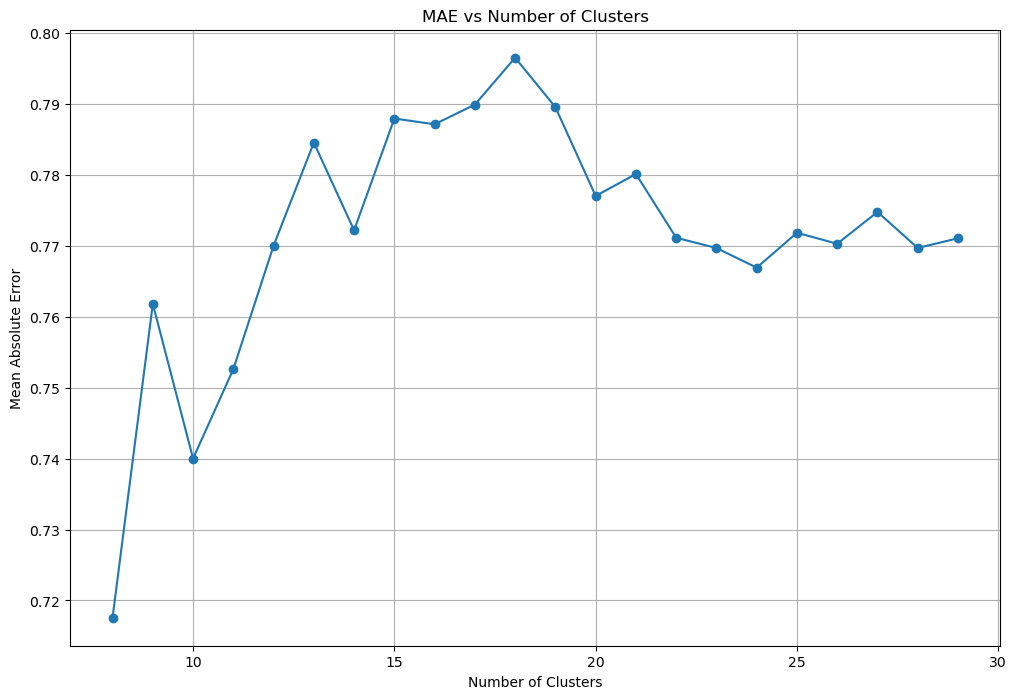

In [91]:
# plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(clusters, spearmans, marker='o')
plt.grid()
plt.title('MAE vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Mean Absolute Error')


Final Thesis Recommendation

In your discussion, you can turn the "lack of a test set" into a strength by performing a Sensitivity Analysis:

Select k=10 as your "Primary Model" because it is the most parsimonious (simplest) and uses the fewest features.

Report the Aggregate Results: Don't just show Seed 31. Show the average of all seeds for k=10.

Include the k-Sensitivity Plot: Show the R 
2
  for k∈{8,10,12,…,28}.

This proves that your result isn't a "one-off" fluke at one specific number.

It shows that the "Skill Signal" exists across the entire scale, even if it's easiest to catch at k=10.

In [57]:
for seed in random.sample(range(100), 1):
    #with normal k means
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=10, random_state=seed, model_type='kmeans', n_init=10,
                                feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                log_feats=['total_path','path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                power_feats=None)

    # => either go with this or total_path instead of vel_p90, but not both since they are redundant

    selector = NestedFeatureSelector(
        top_n=4, 
        pr2_threshold=0.00,         # how much additional variance is needed to be selected
        corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
    )

    model = RidgeCV(alphas=np.logspace(-1, 2, 20))

    #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


    results_df, profile_df = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=['velocity_corr'], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id', 
                vocab=vocab,
                selector=selector,
                model=model
    )

seed: 29


Running LOSO: 100%|██████████| 28/28 [01:11<00:00,  2.54s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.4539 ± 3.6393
Spearman R: 0.7806
Overall R2: 0.6182
Number of selected features: 4.00 ± 0.00


In [62]:
for seed in random.sample(range(100), 1):
    #with normal k means, seed 62 is good!
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=5,
                                feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                power_feats=None)

    # => either go with this or total_path instead of vel_p90, but not both since they are redundant

    selector = NestedFeatureSelector(
        top_n=5, 
        pr2_threshold=0.00,         # how much additional variance is needed to be selected
        corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
    )

    model = RidgeCV(alphas=np.logspace(-1, 2, 20))

    #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


    results_df, profile_df, fold_centroids = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=['velocity_corr'], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id', 
                vocab=vocab,
                selector=selector,
                model=model
    )

seed: 61


Running LOSO: 100%|██████████| 28/28 [01:23<00:00,  2.97s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7247 ± 3.5592
Spearman R: 0.7786
Overall R2: 0.5961
Number of selected features: 5.00 ± 0.00


"While standard KMeans provides a more precise geometric minimization of inertia, MiniBatchKMeans was found to yield superior predictive performance. This suggests that the stochastic nature of the mini-batch updates provides a regularizing effect, preventing the 'cluster collapse' into high-density expert regions and allowing the Bag-of-Words model to better generalize across surgeons in the LOSO cross-validation." 

"While MiniBatchKMeans provided initial regularization through stochastic noise, Standard KMeans with a refined cluster count (k=24) provided a more stable geometric partitioning of the surgical motion space. This transition reduced the variance across random initializations from ±0.04 to ±0.01 in R 
2
 , suggesting that the model successfully converged to a consistent surgical 'vocabulary' that generalizes across different surgeons."

### Elbow for cluster number justification

In [35]:
from sklearn.metrics import silhouette_score
from tqdm import tqdm

# Note: Silhouette is slow on large data, use a subsample of 10,000 frames
def plot_silhouette(df_processed, k_range=range(2, 26, 1)):
    scores = []
    # Subsample for speed
    X_sub = df_processed[np.random.choice(df_processed.shape[0], 10000, replace=False)]
    #X_sub = df_processed.copy()
    
    for k in tqdm(k_range):
        km = KMeans(n_clusters=k, n_init=5, random_state=42).fit(X_sub)
        score = silhouette_score(X_sub, km.labels_)
        scores.append(score)
        
    plt.plot(k_range, scores, 'ro-')
    plt.title('Silhouette Score (Cluster Distinctness)')
    plt.show()

100%|██████████| 24/24 [00:45<00:00,  1.91s/it]


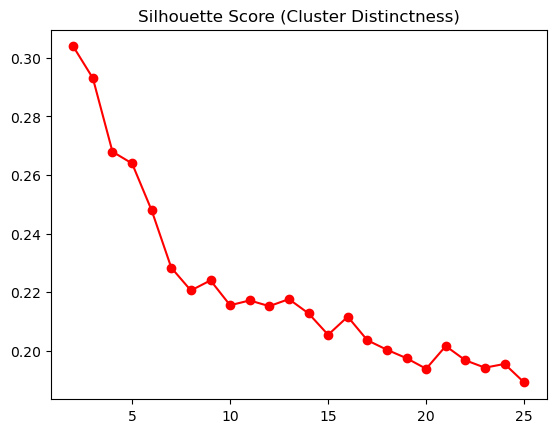

In [36]:
# elbow
X_all = vocab._preprocess(df_window, fit=True)
plot_silhouette(X_all)

array([[<Axes: title={'center': 'path_ratio'}>,
        <Axes: title={'center': 'spatial_spread'}>],
       [<Axes: title={'center': 'palm_area_cv'}>,
        <Axes: title={'center': 'sparc'}>]], dtype=object)

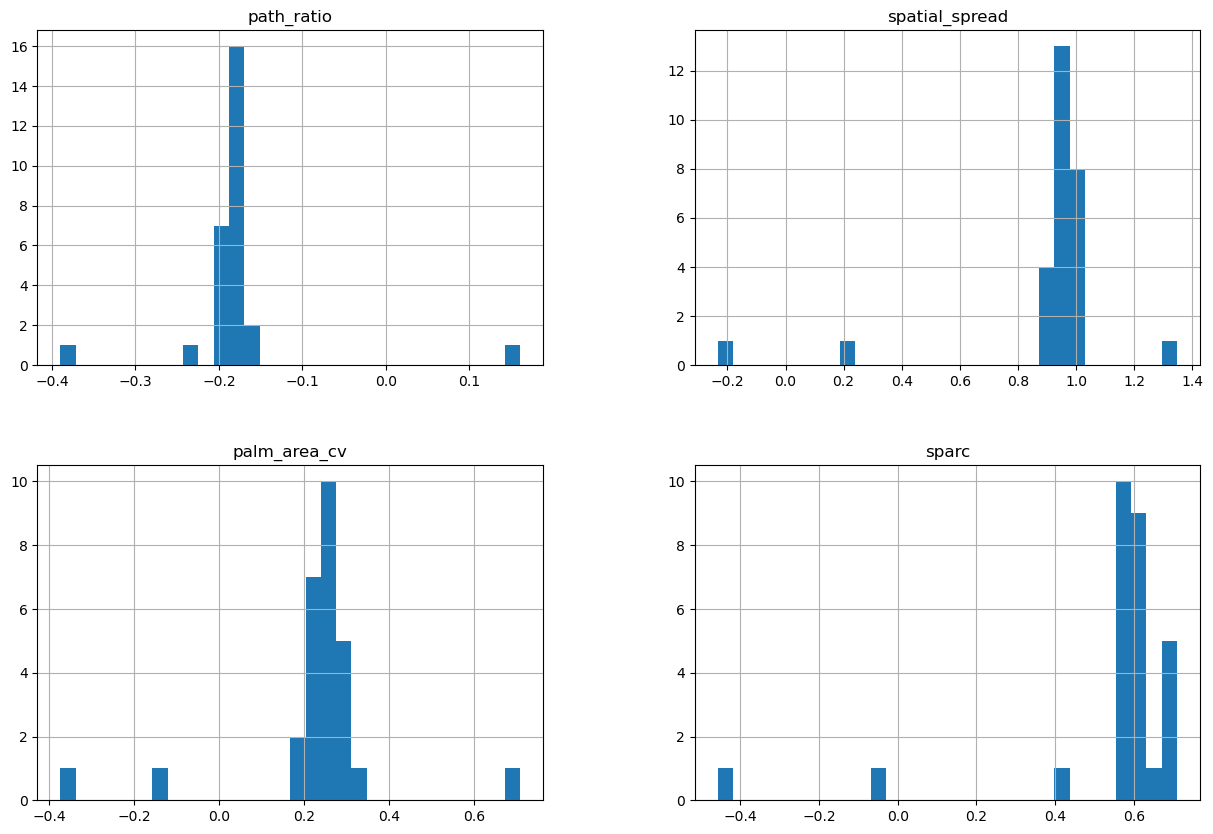

In [42]:

idx = profile_df.groupby('Surgeon_Out')['PR2'].idxmax()
profile_df.loc[idx][vocab.feature_cols].hist(bins=30, figsize=(15, 10))

In [ ]:
# group by index and make a plot for all selected 

array([[<Axes: title={'center': 'path_ratio'}>,
        <Axes: title={'center': 'spatial_spread'}>],
       [<Axes: title={'center': 'palm_area_cv'}>,
        <Axes: title={'center': 'sparc'}>]], dtype=object)

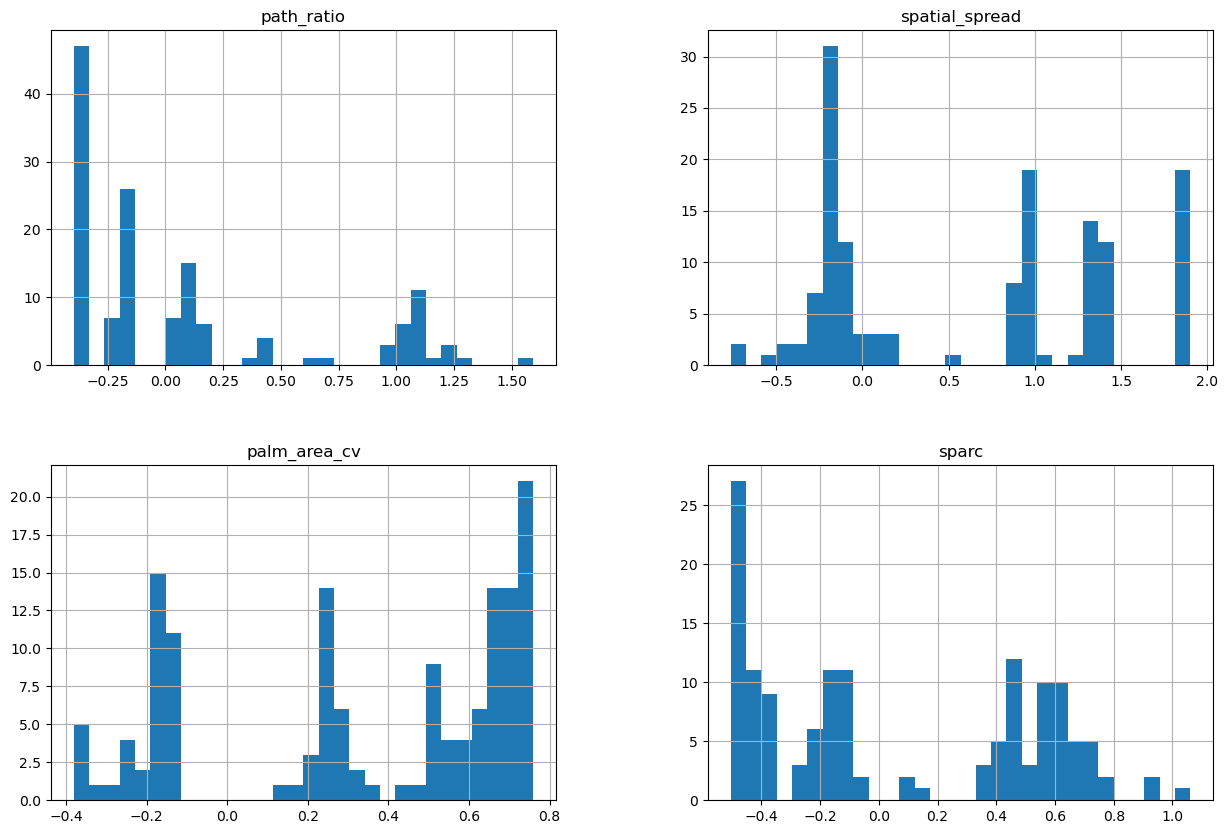

In [38]:
# histogrames of each feat:
profile_df[vocab.feature_cols].hist(bins=30, figsize=(15, 10))

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def identify_consensus_surgemes(profile_df, feature_cols, n_meta_clusters=None):
    """
    Groups the selected centroids from all LOSO folds into 
    consensus 'Meta-SurgeMes'.
    """
    # 1. Extract the coordinates of all selected centroids
    X_meta = profile_df[feature_cols].values
    
    # 2. Determine number of Meta-Clusters (if not provided)
    # Usually, if you have 16 clusters per fold, you might find 
    # 3-6 'consensus' behaviors that actually drive the score.
    if n_meta_clusters is None:
        # Simple heuristic: find the best silhouette score
        best_n = 2
        best_s = -1
        for n in range(2, 20):
            km = KMeans(n_clusters=n, random_state=42).fit(X_meta)
            s = silhouette_score(X_meta, km.labels_)
            print(f"Silhouette for n={n}: {s:.4f}")
            if s > best_s:
                best_s = s
                best_n = n
        n_meta_clusters = best_n
        print(f"Optimal number of Meta-Clusters: {n_meta_clusters} with silhouette score: {best_s:.4f}")

    # 3. Fit Meta-Clustering
    meta_km = KMeans(n_clusters=n_meta_clusters, random_state=42)
    profile_df['Meta_Cluster_ID'] = meta_km.fit_transform(X_meta).argmin(axis=1) # Get labels
    
    # 4. Create the 'Consensus Table'
    # This averages the kinematic signatures of each consensus behavior
    consensus_table = profile_df.groupby('Meta_Cluster_ID')[feature_cols].mean()
    
    # 5. Calculate 'Selection Frequency'
    # How many folds out of the total LOSO folds picked this type of behavior?
    # This is a proxy for how 'universal' the behavior is.
    counts = profile_df['Meta_Cluster_ID'].value_counts()
    consensus_table['Fold_Frequency'] = counts / profile_df['Surgeon_Out'].nunique()
    
    return consensus_table, profile_df

In [40]:
consensus_table, annotated_profiles = identify_consensus_surgemes(profile_df, feature_cols=vocab.feature_cols)

Silhouette for n=2: 0.5511
Silhouette for n=3: 0.6001
Silhouette for n=4: 0.6816
Silhouette for n=5: 0.7406
Silhouette for n=6: 0.7850
Silhouette for n=7: 0.8231
Silhouette for n=8: 0.8285
Silhouette for n=9: 0.8447
Silhouette for n=10: 0.8494
Silhouette for n=11: 0.7804
Silhouette for n=12: 0.7840
Silhouette for n=13: 0.7915
Silhouette for n=14: 0.7940
Silhouette for n=15: 0.8016
Silhouette for n=16: 0.7246
Silhouette for n=17: 0.6732
Silhouette for n=18: 0.6572
Silhouette for n=19: 0.5755
Optimal number of Meta-Clusters: 10 with silhouette score: 0.8494


In [254]:
consensus_table

,total_path,path_ratio,spatial_spread,palm_area_cv,sparc,Fold_Frequency
Meta_Cluster_ID,,,,,,
0,0.121636,-0.303128,0.604569,-0.231432,-0.454517,0.428571
1,1.017818,-0.319230,1.611045,0.364328,-0.330158,1.000000
2,0.070158,-0.108210,0.307684,-0.104613,0.673518,1.000000
3,0.075939,0.241208,0.079297,0.786283,-0.063874,0.142857
4,-0.384271,0.999762,-0.660291,-0.131526,0.153373,0.214286
5,0.212401,0.858883,-0.228960,0.561309,1.377821,0.214286
6,0.430032,-0.297356,0.940873,-0.052638,-0.402068,0.357143
7,0.542152,2.060127,-0.050742,0.540170,0.420737,0.035714
8,-0.140174,0.009903,0.020076,0.793045,-0.122460,0.607143


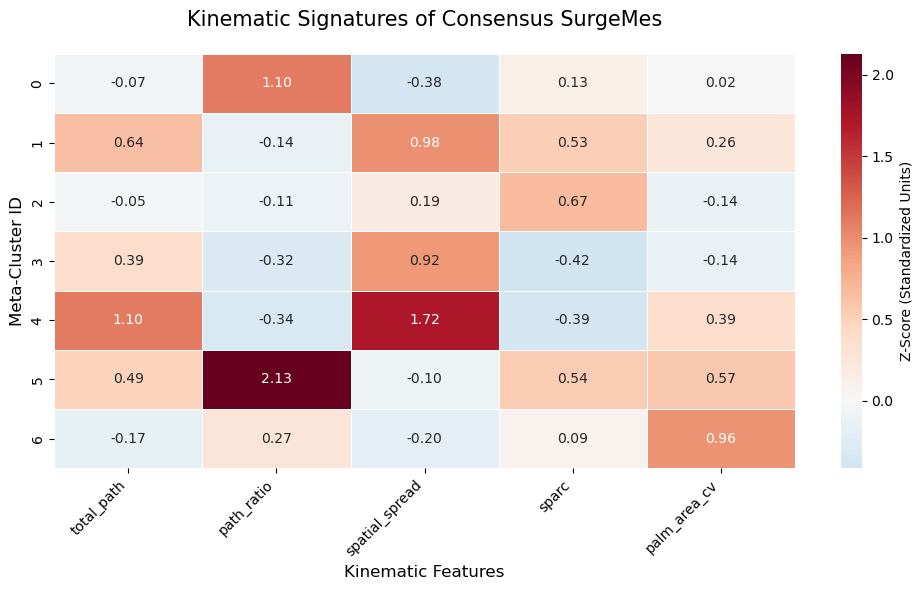

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_consensus_heatmap(consensus_table, feature_cols):
    """
    Plots a heatmap of the kinematic signatures of Consensus SurgeMes.
    """
    # 1. Isolate the kinematic features for the heatmap
    # We exclude 'Fold_Frequency' and 'PR2' for the main colors
    plot_data = consensus_table[feature_cols]
    
    # 2. Setup the figure
    plt.figure(figsize=(10, 6))
    
    # 3. Create Heatmap
    # cmap='RdBu_r' is perfect for Z-scores (Red = High, Blue = Low)
    # center=0 ensures that the "average" is white
    sns.heatmap(
        plot_data, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu_r', 
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Z-Score (Standardized Units)'}
    )
    
    plt.title('Kinematic Signatures of Consensus SurgeMes', fontsize=15, pad=20)
    plt.xlabel('Kinematic Features', fontsize=12)
    plt.ylabel('Meta-Cluster ID', fontsize=12)
    
    # Optional: Rotate labels for better fit
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Execution
consensus_table, profile_df = identify_consensus_surgemes(profile_df, vocab.feature_cols)
plot_consensus_heatmap(consensus_table, vocab.feature_cols)

# Align Fold Centroids To A Global Template

In [67]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import euclidean_distances

def align_fold_centroids(global_centroids, fold_centroids_list):
    """
    global_centroids: (K, 4) array from K-Means on the full dataset.
    fold_centroids_list: A list of (K, 4) arrays, one for each of your 28 LOSO folds.
    """
    aligned_data = []
    K = global_centroids.shape[0]

    for fold_idx, f_cents in enumerate(fold_centroids_list):
        # 1. Compute distance matrix between Global and this Fold's centroids
        # cost_matrix[i, j] is the distance between Global Cluster i and Fold Cluster j
        cost_matrix = euclidean_distances(global_centroids, f_cents)
        
        # 2. Find the optimal one-to-one mapping (Hungarian Algorithm)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        # 3. Reorder the fold centroids to match the global template order
        # col_ind tells us which index in f_cents matches 0, 1, 2... in global
        for i, j in zip(row_ind, col_ind):
            aligned_data.append({
                'fold': fold_idx,
                'cluster_id': i,  # This is the "Global Name"
                'path_ratio': f_cents[j, 0],
                'spatial_spread': f_cents[j, 1],
                'sparc': f_cents[j, 2],
                'palm_area_cv': f_cents[j, 3]
            })
            
    return pd.DataFrame(aligned_data)

In [79]:
# do different seed produce very similar global scale clusters
vocab_ref = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=20,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          power_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )

vocab_ref.fit(df_window)

global_centers = vocab_ref.model.cluster_centers_

comp_cluster_centers = []

for seed in tqdm(random.sample(range(40), 10)):
    vocab_temp = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=20,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          power_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )
    vocab_temp.fit(df_window)
    comp_cluster_centers.append(vocab_temp.model.cluster_centers_)

100%|██████████| 10/10 [00:39<00:00,  3.93s/it]


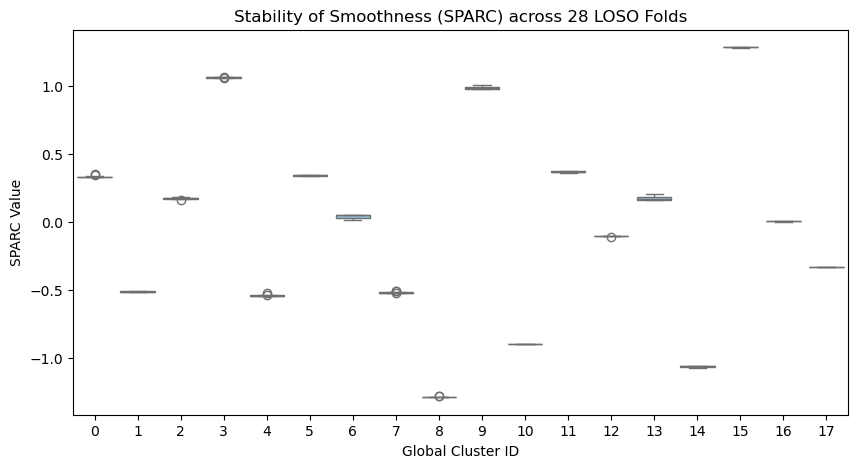

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

global_centers = vocab_ref.model.cluster_centers_
df_stability = align_fold_centroids(global_centers, comp_cluster_centers)

# Let's look at 'sparc' stability across the 18 clusters
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_stability, x='cluster_id', y='spatial_spread', color='skyblue')
plt.title("Stability of Smoothness (SPARC) across 28 LOSO Folds")
plt.xlabel("Global Cluster ID")
plt.ylabel("SPARC Value")
plt.show()

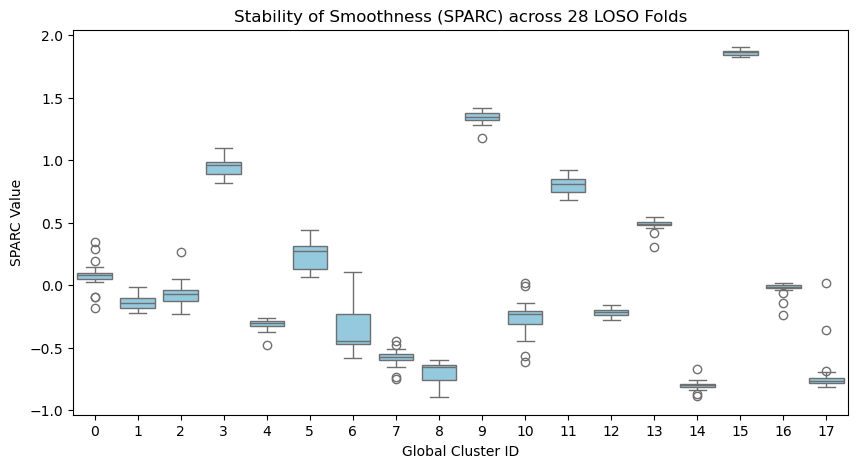

In [81]:
global_centers = vocab_ref.model.cluster_centers_
df_stability = align_fold_centroids(global_centers, fold_centroids)

# Let's look at 'sparc' stability across the 18 clusters
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_stability, x='cluster_id', y='spatial_spread', color='skyblue')
plt.title("Stability of Smoothness (SPARC) across 28 LOSO Folds")
plt.xlabel("Global Cluster ID")
plt.ylabel("SPARC Value")
plt.show()

### **Lasso CV directly with all BoWs**

In [209]:
from sklearn.linear_model import LassoCV, ElasticNetCV, ElasticNet

vocab = KinematicVocabulary(n_clusters=9, random_state=40, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'])

#model = ElasticNet(alpha=0.5, l1_ratio=0.5)
model = ElasticNetCV(alphas=np.logspace(-1, 2, 30), l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9])

results_df, profile_df = run_hybrid_vocabulary_loso(
            df_videos=df_pc1_features, 
            df_windows=df_window, 
            primary_features=pc1_features, 
            extra_features=['velocity_corr'], 
            target_col='QRS_Overal', 
            surgeon_col='Participant Number', 
            video_col='video_id', 
            vocab=vocab,
            model=model
)

Running LOSO:   0%|          | 0/28 [00:00<?, ?it/s]

Running LOSO: 100%|██████████| 28/28 [00:33<00:00,  1.21s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8255 ± 3.8814
Spearman R: 0.7416
Overall R2: 0.5573
Number of selected features: 9.00 ± 0.00
